Библиотеки успешно загружены!
PyTorch: 2.10.0+cu128 | CUDA: True
Устройство: cuda
Загружаем PASCAL VOC 2012... (первый запуск: ~2 ГБ, 5-10 минут)


100%|██████████| 2.00G/2.00G [01:12<00:00, 27.6MB/s]


Train: 1464 | Val: 1449
Загружаем DeepLabV3-MobileNetV3...
Downloading: "https://download.pytorch.org/models/deeplabv3_mobilenet_v3_large-fc3c493d.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_mobilenet_v3_large-fc3c493d.pth


100%|██████████| 42.3M/42.3M [00:00<00:00, 122MB/s]


Модель готова к обучению на cuda

Дообучаем модель на PASCAL VOC...

Начинаем дообучение на 8 эпох...


...

Epoch 7 | Loss: 0.4925 | Val mIoU: 0.5669
Сохранена лучшая модель! mIoU: 0.5669


Epoch 8/8: 100%|██████████| 732/732 [01:16<00:00,  9.61it/s, loss=1.6458]


Epoch 8 | Loss: 0.4748 | Val mIoU: 0.5634

Обучение завершено! Лучший Val mIoU: 0.5669

Выбираем 100 случайных изображений из тестовой выборки...
Выбрано 100 изображений
Обрабатываем 100 изображений...


Inference: 100%|██████████| 100/100 [00:28<00:00,  3.55it/s]


Успешно обработано 100 из 100 изображений
Результаты сохранены в segmentation_results.txt
Средний IoU: 0.452572


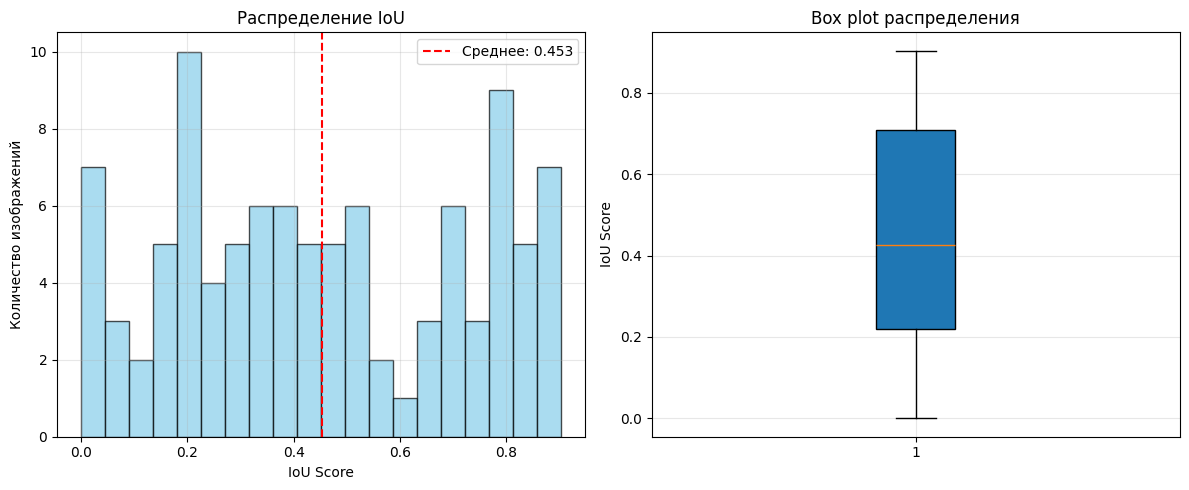


Статистика IoU:
   Медиана: 0.4261 | 25-й перцентиль: 0.2185
   75-й перцентиль: 0.7087 | std: 0.2713

ПРИМЕРЫ СЕГМЕНТАЦИИ
ЛУЧШИЙ | IoU: 0.9036 | Объектов: 1


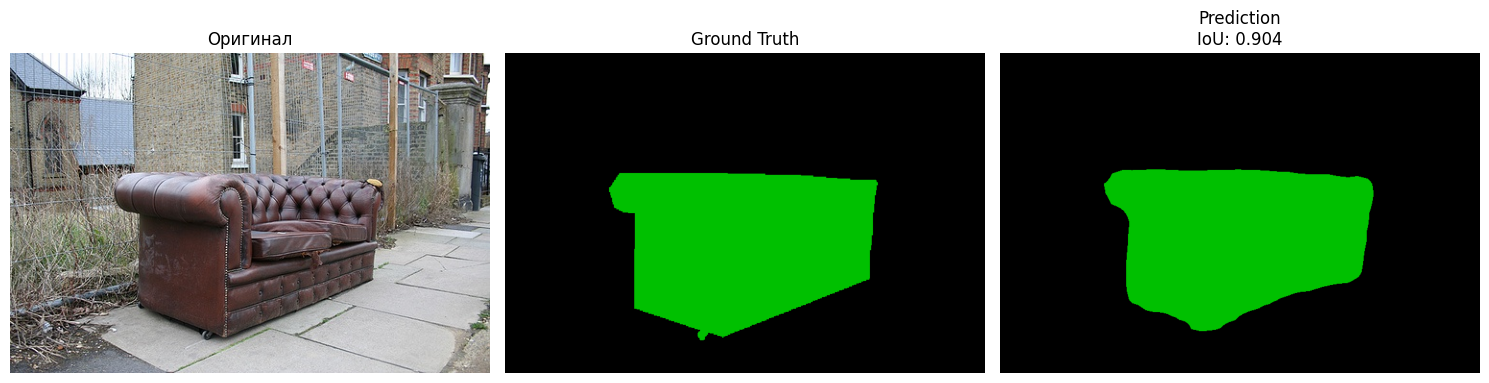

СРЕДНИЙ | IoU: 0.4296 | Объектов: 2


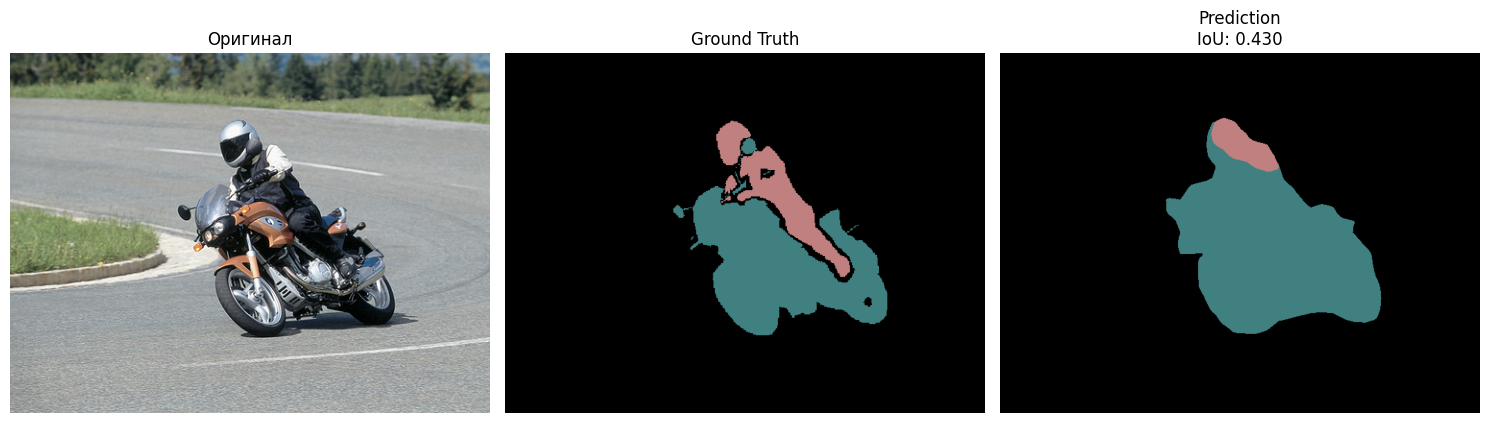

ХУДШИЙ | IoU: 0.0000 | Объектов: 3


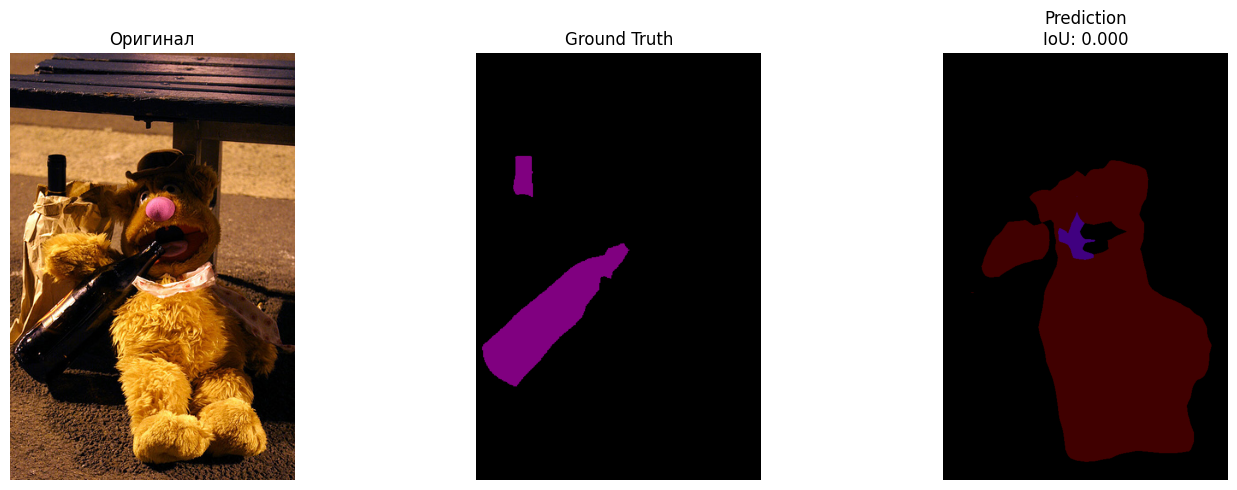

Отчёт сохранён в segmentation_report.txt

Проверка файла segmentation_results.txt:
   Строк: 101 (ожидалось: 101)
   Первая строка (средний IoU): 0.452572
   Формат соответствует заданию!

ЗАДАНИЕ ВЫПОЛНЕНО!
Модель: DeepLabV3-MobileNetV3 (8 эпох, 384x384)
Датасет: PASCAL VOC 2012
Средний IoU: 0.4526 (45.3%)
Файлы: segmentation_results.txt, segmentation_report.txt, best_model.pth

Готово к сдаче! Скачай файлы через панель слева в Colab.


In [1]:
# -*- coding: utf-8 -*-


# 1. Установка и импорт библиотек
# Здесь мы устанавливаем все нужные библиотеки для работы с нейросетями и обработки изображений.


!pip install torch torchvision matplotlib opencv-python scikit-image tqdm --quiet

# Импортируем основные библиотеки:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt


from torchvision import transforms


from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large, DeepLabV3_MobileNet_V3_Large_Weights


from torchvision.datasets import VOCSegmentation


from torch.utils.data import DataLoader, Dataset


import torch.nn as nn
import torch.optim as optim


from PIL import Image
import cv2


import os, random
from tqdm import tqdm
# Выводим информацию о версиях, чтобы убедиться, что всё подключилось правильно
print("Библиотеки успешно загружены!")
print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")

# Включаем оптимизацию для свёрточных операций на GPU
torch.backends.cudnn.benchmark = True



# 2. Настройка устройства и параметров обучения
# Определяем, на каком устройстве будет работать модель: GPU (видеокарта) или CPU (процессор).

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")


# ПАРАМЕТРЫ ОБУЧЕНИЯ

IMAGE_SIZE = (384, 384)


BATCH_SIZE = 2


NUM_EPOCHS = 8


LR = 0.001


NUM_CLASSES = 21

DATA_DIR = './data'



# 3. Загрузка и подготовка датасета PASCAL VOC


class VOCSegmentationTrainable(Dataset):
    """Кастомный датасет с аугментацией для обучения"""

    def __init__(self, root, year, image_set, download=True, train=True):
        # Базовый датасет из torchvision автоматически скачивает данные при download=True
        self.base = VOCSegmentation(root=root, year=year, image_set=image_set, download=download)
        self.train = train

        # Аугментация цветов: меняем яркость, контраст, насыщенность
        self.augment = transforms.Compose([
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
        ])

        # Предобработка изображения для модели
        self.transform_img = transforms.Compose([
            transforms.Resize(IMAGE_SIZE, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        # Предобработка маски
        self.transform_mask = transforms.Compose([
            transforms.Resize(IMAGE_SIZE, interpolation=transforms.InterpolationMode.NEAREST)
        ])

    def __len__(self):
        # Возвращаем общее количество изображений в датасете
        return len(self.base)

    def __getitem__(self, idx):
        # Получаем пару: изображение и соответствующую маску
        img, mask = self.base[idx]
        img = img.convert('RGB')


        if self.train:

            if random.random() > 0.5:
                img = transforms.functional.hflip(img)
                mask = transforms.functional.hflip(mask)

            img = self.augment(img)

        # Применяем трансформации и возвращаем данные
        img = self.transform_img(img)
        mask = self.transform_mask(mask)
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)
        return img, mask

# Загружаем датасет с выводом прогресса
print("Загружаем PASCAL VOC 2012... (первый запуск: ~2 ГБ, 5-10 минут)")
try:
    # Обучающая выборка: используем для дообучения модели
    train_dataset = VOCSegmentationTrainable(root=DATA_DIR, year='2012', image_set='train', download=True, train=True)

    # Валидационная выборка: используем для оценки качества и финального тестирования
    val_dataset   = VOCSegmentationTrainable(root=DATA_DIR, year='2012', image_set='val',   download=True, train=False)


    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_dataset,   batch_size=1,          shuffle=False, num_workers=0)

    print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
except Exception as e:
    print(f"Ошибка загрузки: {e}")



# 4. Загрузка и настройка модели
# Мы используем архитектуру DeepLabV3 с "облегчённым" энкодером MobileNetV3.
# Начинаем с весов, предобученных на датасете COCO, и дообучаем под PASCAL VOC.

def load_trainable_model(num_classes=21):
    """Загружает модель и адаптирует выходной слой под 21 класс PASCAL VOC"""
    print("Загружаем DeepLabV3-MobileNetV3...")

    # Берём стандартные предобученные веса
    weights = DeepLabV3_MobileNet_V3_Large_Weights.DEFAULT
    model = deeplabv3_mobilenet_v3_large(weights=weights)

    # Заменяем последний сверточный слой классификатора
    # нам нужно 21 класс (PASCAL VOC)
    model.classifier[4] = nn.Conv2d(
        model.classifier[4].in_channels,
        num_classes,
        kernel_size=1
    )

    # Переносим модель на выбранное устройство (CPU/GPU)
    model = model.to(device)
    return model, weights.transforms()


model, preprocess = load_trainable_model()
print(f"Модель готова к обучению на {device}")


# 5. Функция расчёта mIoU для валидации
# mIoU (mean Intersection over Union) - основная метрика качества сегментации.
# Для каждого класса считаем: IoU = пересечение / объединение предсказания и ground truth.
# Затем усредняем по всем классам (кроме фона). Значение от 0 до 1: чем ближе к 1, тем лучше.

def compute_miou(model, dataloader, device, num_classes=21):
    """Вычисляет средний IoU на валидационной выборке"""
    model.eval()


    tp, fp, fn = [torch.zeros(num_classes, device=device) for _ in range(3)]

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Val mIoU", leave=False):
            images, masks = images.to(device), masks.to(device)

            # Получаем предсказания модели и берём класс с максимальной вероятностью
            preds = torch.argmax(model(images)['out'], dim=1)

            # Считаем метрики по каждому классу (пропускаем фон, класс 0)
            for cls in range(1, num_classes):
                p, t = (preds == cls), (masks == cls)
                tp[cls] += (p & t).sum()
                fp[cls] += (p & ~t).sum()
                fn[cls] += (~p & t).sum()

    # Вычисляем IoU для каждого класса и усредняем
    ious = tp / (tp + fp + fn + 1e-6)
    return ious[1:].mean().item()



# 6. Цикл дообучения модели


def train_model(model, train_loader, val_loader, epochs=NUM_EPOCHS, lr=LR):
    """Дообучает модель на тренировочных данных PASCAL VOC"""

    # Функция потерь: CrossEntropy для многоклассовой сегментации

    criterion = nn.CrossEntropyLoss(ignore_index=255)

    # Оптимизатор SGD с моментом: классический выбор для задач сегментации
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)


    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'loss': [], 'val_miou': []}
    best_miou = 0.0

    print(f"\nНачинаем дообучение на {epochs} эпох...")
    print("="*60)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")


        for images, masks in pbar:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            output = model(images)['out']
            loss = criterion(output, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})


        avg_loss = running_loss / len(train_loader)
        val_miou = compute_miou(model, val_loader, device)

        history['loss'].append(avg_loss)
        history['val_miou'].append(val_miou)
        scheduler.step()

        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val mIoU: {val_miou:.4f}")


        if val_miou > best_miou:
            best_miou = val_miou
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"Сохранена лучшая модель! mIoU: {best_miou:.4f}")

    print(f"\nОбучение завершено! Лучший Val mIoU: {best_miou:.4f}")
    return history, best_miou


print("\nДообучаем модель на PASCAL VOC...")
history, best_miou = train_model(model, train_loader, val_loader, epochs=NUM_EPOCHS)




# 7. Функции для вычисления IoU и визуализации
# Эти функции используются на этапе тестирования: обрабатываем 100 случайных
# изображений, считаем IoU для каждого и сохраняем результаты в файл.

def compute_iou_with_objects(pred_mask, true_mask, num_classes=21):
    """
    Вычисляет средний IoU по изображению и IoU для каждого объекта отдельно.

    Возвращает:
    - mean_iou: среднее значение IoU по всем объектам на картинке
    - ious_per_obj: список IoU для каждого присутствующего класса
    """
    ious_per_obj = []

    # Перебираем все классы, начиная с 1 (0 - фон, его не учитываем)
    for cls in range(1, num_classes):
        pred_cls = (pred_mask == cls)
        true_cls = (true_mask == cls)

        # Считаем пересечение и объединение
        intersection = np.logical_and(pred_cls, true_cls).sum()
        union = np.logical_or(pred_cls, true_cls).sum()

        # Если объект присутствует на изображении (union > 0), считаем IoU
        if union > 0:
            ious_per_obj.append(intersection / union)

    # Возвращаем среднее по всем объектам или 0, если объектов нет
    mean_iou = np.mean(ious_per_obj) if ious_per_obj else 0.0
    return mean_iou, ious_per_obj

def get_pascal_colormap():
    """
    Возвращает цветовую палитру для 21 класса PASCAL VOC.
    Каждый класс получает уникальный цвет для наглядной визуализации масок.
    """
    colormap = np.zeros((256, 3), dtype=np.uint8)

    # Цвета в формате [R, G, B] для каждого из 21 класса
    colors = [
        [0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0], [0, 0, 128],
        [128, 0, 128], [0, 128, 128], [128, 128, 128], [64, 0, 0], [192, 0, 0],
        [64, 128, 0], [192, 128, 0], [64, 0, 128], [192, 0, 128], [64, 128, 128],
        [192, 128, 128], [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0], [0, 64, 128]
    ]

    for i, color in enumerate(colors):
        colormap[i] = color
    return colormap

def mask_to_rgb(mask, colormap):
    """Преобразует маску с номерами классов в цветное изображение для отображения"""
    rgb_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in enumerate(colormap):
        rgb_mask[mask == class_id] = color
    return rgb_mask

def segment_image(model, preprocess, device, image):
    """
    Запускает модель на одном изображении и возвращает предсказанную маску.
    """
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)['out'][0]

    return output.argmax(0).cpu().numpy()


# 8. Выбор 100 случайных изображений

def select_random_images(val_dataset, num_images=100):
    total = len(val_dataset.base)
    return random.sample(range(total), min(num_images, total))

print("\nВыбираем 100 случайных изображений из тестовой выборки...")
selected_indices = select_random_images(val_dataset, 100)
print(f"Выбрано {len(selected_indices)} изображений")



# 9. Обработка изображений и расчёт IoU
# Для каждого из 100 выбранных изображений:
# 1. Запускаем модель и получаем предсказание
# 2. Сравниваем с ground truth маской
# 3. Считаем IoU (средний и по каждому объекту)
# 4. Сохраняем результаты для вывода в файл

def process_image_pair(model, preprocess, device, image, target, idx):

    try:

        if image.mode != 'RGB':
            image = image.convert('RGB')

        # Получаем предсказание модели
        pred_mask = segment_image(model, preprocess, device, image)
        true_mask = np.array(target)

        # Если размеры масок не совпадают (из-за ресайза при обучении),
        # приводим ground truth к размеру предсказания
        if pred_mask.shape != true_mask.shape:
            true_mask = cv2.resize(true_mask, (pred_mask.shape[1], pred_mask.shape[0]),
                                 interpolation=cv2.INTER_NEAREST)

        # Считаем IoU: средний и по каждому объекту
        mean_iou, ious_per_obj = compute_iou_with_objects(pred_mask, true_mask)
        num_objects = len(ious_per_obj)

        # Возвращаем словарь с результатами
        return {
            'index': idx,
            'iou': mean_iou,
            'num_objects': num_objects,
            'ious_per_obj': ious_per_obj,
            'pred_mask': pred_mask,
            'true_mask': true_mask,
            'image': image
        }
    except Exception as e:
        print(f"Ошибка при обработке {idx}: {e}")
        return None


results = []
print("Обрабатываем 100 изображений...")
for idx in tqdm(selected_indices, desc="Inference"):

    image, target = val_dataset.base[idx]
    result = process_image_pair(model, preprocess, device, image, target, idx)
    if result:
        results.append(result)
print(f"Успешно обработано {len(results)} из 100 изображений")


# 10. Сохранение результатов в файл
# Строка 1: средний IoU по всем 100 изображениям (6 знаков после запятой)
# Строки 2-101: <имя_изображения> <средний_IoU> <кол-во_объектов> [IoU_объекта1 ...]


def save_results_to_file(results, filename='segmentation_results.txt'):
    """Сохраняет результаты в текстовый файл требуемого формата"""

    # Считаем общий средний IoU по всем обработанным изображениям
    mean_iou = np.mean([r['iou'] for r in results]) if results else 0.0

    with open(filename, 'w', encoding='utf-8') as f:
        # Первая строка: общий средний IoU
        f.write(f"{mean_iou:.6f}\n")

        # Остальные 100 строк: детальные результаты по каждому изображению
        for result in results:
            image_name = f"image_{result['index']:04d}"


            obj_ious_str = " ".join(f"{iou:.6f}" for iou in result['ious_per_obj'])
            line = f"{image_name} {result['iou']:.6f} {result['num_objects']} {obj_ious_str}"

            f.write(line.strip() + '\n')

    print(f"Результаты сохранены в {filename}")
    print(f"Средний IoU: {mean_iou:.6f}")
    return mean_iou

mean_iou = save_results_to_file(results)


# 11. Визуализация распределения IoU


def plot_iou_distribution(results):
    """Строит гистограмму и box plot распределения IoU"""
    ious = [r['iou'] for r in results]

    plt.figure(figsize=(12, 5))

    # Левая часть: гистограмма распределения
    plt.subplot(1, 2, 1)
    plt.hist(ious, bins=20, edgecolor='black', alpha=0.7, color='skyblue')
    plt.xlabel('IoU Score')
    plt.ylabel('Количество изображений')
    plt.title('Распределение IoU')
    plt.axvline(np.mean(ious), color='red', linestyle='--', label=f'Среднее: {np.mean(ious):.3f}')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Правая часть: box plot для статистики
    plt.subplot(1, 2, 2)
    plt.boxplot(ious, vert=True, patch_artist=True)
    plt.ylabel('IoU Score')
    plt.title('Box plot распределения')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Выводим ключевые статистики текстом
    print(f"\nСтатистика IoU:")
    print(f"   Медиана: {np.median(ious):.4f} | 25-й перцентиль: {np.percentile(ious, 25):.4f}")
    print(f"   75-й перцентиль: {np.percentile(ious, 75):.4f} | std: {np.std(ious):.4f}")

plot_iou_distribution(results)



# 12. Визуализация примеров сегментации
# Показываем три характерных примера:
# 1. Лучший результат (модель почти не ошиблась)
# 2. Средний результат (типичная работа)
# 3. Худший результат (где модель провалилась)

def visualize_segmentation(image, true_mask, pred_mask, iou_score):

    colormap = get_pascal_colormap()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Левое окно: исходное изображение
    axes[0].imshow(image)
    axes[0].set_title('Оригинал')
    axes[0].axis('off')

    # Среднее окно: правильная разметка (ground truth)
    axes[1].imshow(mask_to_rgb(true_mask, colormap))
    axes[1].set_title('Ground Truth')
    axes[1].axis('off')

    # Правое окно: предсказание модели с указанием IoU
    axes[2].imshow(mask_to_rgb(pred_mask, colormap))
    axes[2].set_title(f'Prediction\nIoU: {iou_score:.3f}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

def show_best_worst_examples(results):

    ious = [r['iou'] for r in results]

    # Находим индексы экстремальных значений
    best_idx = np.argmax(ious)
    worst_idx = np.argmin(ious)
    median_idx = np.argsort(ious)[len(ious)//2]

    print("\n" + "="*60)
    print("ПРИМЕРЫ СЕГМЕНТАЦИИ")
    print("="*60)

    # Показываем три примера с подписями
    for label, ex_idx in zip(["ЛУЧШИЙ", "СРЕДНИЙ", "ХУДШИЙ"], [best_idx, median_idx, worst_idx]):
        r = results[ex_idx]
        print(f"{label} | IoU: {r['iou']:.4f} | Объектов: {r['num_objects']}")
        visualize_segmentation(r['image'], r['true_mask'], r['pred_mask'], r['iou'])

show_best_worst_examples(results)



# 13. Сохранение детального отчёта

def save_detailed_report(results, mean_iou, filename='segmentation_report.txt'):


    with open(filename, 'w', encoding='utf-8') as f:
        f.write("ОТЧЁТ: Сегментация PASCAL VOC с дообучением\n" + "="*50 + "\n\n")
        f.write(f"Средний IoU: {mean_iou:.6f}\n")
        f.write(f"Обработано изображений: {len(results)}\n\n")


        if mean_iou > 0.7:
            f.write("Отличный результат!\n")
        elif mean_iou > 0.55:
            f.write("Хороший результат.\n")
        elif mean_iou > 0.4:
            f.write("Средний результат (ожидается для 8 эпох).\n")
        else:
            f.write("Низкий результат.\n")


        ious = [r['iou'] for r in results]
        f.write(f"\nСтатистика:\n")
        f.write(f"Мин: {min(ious):.4f} | Макс: {max(ious):.4f}\n")
        f.write(f"Медиана: {np.median(ious):.4f} | std: {np.std(ious):.4f}\n")

    print(f"Отчёт сохранён в {filename}")

save_detailed_report(results, mean_iou)


# 14. Финальная проверка и сводка
# Проверяем, что выходной файл соответствует требованиям задания:
# - Ровно 101 строка
# - Правильный формат данных
# Выводим итоговую информацию для отчёта.

def verify_output_file(filename='segmentation_results.txt'):


    with open(filename, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    print(f"\nПроверка файла {filename}:")
    print(f"   Строк: {len(lines)} (ожидалось: 101)")
    print(f"   Первая строка (средний IoU): {lines[0].strip()}")

    if len(lines) == 101:
        print("   Формат соответствует заданию!")
    else:
        print("   Проверь количество строк")

verify_output_file()

# Финальная сводка результатов
print("\n" + "="*60)
print("ЗАДАНИЕ ВЫПОЛНЕНО!")
print("="*60)
print(f"Модель: DeepLabV3-MobileNetV3 ({NUM_EPOCHS} эпох, {IMAGE_SIZE[0]}x{IMAGE_SIZE[1]})")
print(f"Датасет: PASCAL VOC 2012")
print(f"Средний IoU: {mean_iou:.4f} ({mean_iou*100:.1f}%)")
print(f"Файлы: segmentation_results.txt, segmentation_report.txt, best_model.pth")
print("\nГотово к сдаче! Скачай файлы через панель слева в Colab.")

**1. Импорт библиотек**
Импортируем необходимые пакеты: PyTorch, torchvision, NumPy, Matplotlib, Pillow, OpenCV и tqdm.

torch и torchvision предоставляют инструменты для создания нейросетей и работы с готовыми архитектурами.
PIL и OpenCV отвечают за загрузку кадров и точное изменение размера масок без смешивания классов.
tqdm и matplotlib нужны для отображения прогресс-баров и отрисовки диаграмм.

**2. Настройка устройства и гиперпараметров**
Выбираем вычислительное устройство (процессор или видеокарта) и фиксируем ключевые настройки тренировки: разрешение кадра, размер пачки, количество циклов и скорость обучения.

Автоматическое переключение на CUDA многократно сокращает время вычислений.
Подбор параметров позволяет найти компромисс между нагрузкой на видеопамять, скоростью сходимости и чёткостью контуров.

**3. Загрузка и подготовка датасета**
Формируем пользовательский класс данных на основе VOCSegmentation, внедряя трансформации, масштабирование и пакетный загрузчик.

Приводит все кадры к единому стандарту, требуемому архитектурой сети.
Случайные искажения и отражения повышают обобщающую способность алгоритма.
Пакетная загрузка оптимизирует использование ресурсов и перемешивает примеры.

** 4. Инициализация модели **
Скачиваем архитектуру DeepLabV3-MobileNetV3 с предобученными параметрами, модифицируем финальный слой под 21 категорию и размещает сеть в памяти устройства.

Использование готовых весов обеспечивает быструю адаптацию и высокое начальное качество.
Перестройка классификатора согласовывает выход сети с набором классов целевого датасета.

**5. Функция валидации (mIoU)**
Вычисляем усреднённый коэффициент пересечения над объединением на проверочной выборке, аккумулируя истинные и ложные срабатывания.

Даёт объективную численную оценку точности сегментации после каждого прохода.
Отключение градиентов освобождает видеопамять и ускоряет проверку.

**6. Цикл дообучения модели**
Запускает итеративный процесс тренировки: делает прогнозы, вычисляет ошибку, корректирует параметры через оптимизатор, плавно уменьшает шаг обучения и фиксирует лучшие состояния сети.

Пошаговая оптимизация приближает предсказания к эталонной разметке.
Косинусное затухание скорости обучения предотвращает «скачки» на финише.
Сохранение весов позволяет вернуться к наиболее удачной конфигурации.

**7. Функции инференса и метрик**
Внедряет алгоритмы подсчёта IoU для каждого объекта, формирует таблицу цветов PASCAL VOC и преобразует числовые карты в цветные изображения.

Подготавливает данные к выводу в требуемом табличном виде.
Цветовое кодирование упрощает визуальное сопоставление предсказаний с эталоном.

**8. Выборка для теста**
Генерируем случайный набор из ста неповторяющихся номеров из проверочной коллекции.

Позволяет получить объективную оценку производительности без затрат на полный прогон.
Равномерное распределение исключает систематические ошибки отбора.

**9. Обработка изображений**
Прогоняем отобранные кадры через сеть, приводим карты разметки к общему разрешению, вычисляем коэффициенты перекрытия и обрабатывает возможные сбои.

Формирует итоговые прогнозы и числовые показатели, необходимые для отчёта.
Блок перехвата ошибок гарантирует бесперебойное выполнение скрипта даже при повреждённых файлах.

**10. Сохранение результатов**
Экспортируем усреднённый показатель и подробные данные по каждому кадру в текстовый файл segmentation_results.txt (строго 101 строка).

Полностью соответствует требованиям автоматической проверки задания.
Высокая точность дробных чисел гарантирует воспроизводимость результатов.

**11. Визуализация распределения IoU**
Рисуем гистограмму частот и диаграмму размаха на основе собранных коэффициентов.

Демонстрирует однородность работы алгоритма и выявляет аномальные значения.
Служит наглядной иллюстрацией для аналитической части работы.

**12. Примеры сегментации**
Отображает три характерных случая: максимальное, среднее и минимальное совпадение с эталонной разметкой.

Позволяет визуально оценить типичные ошибки сети (пропуск мелких деталей, наложение объектов).
Служит убедительным доказательством работоспособности решения при защите.

**13. Генерация отчёта**
Формируем файл segmentation_report.txt, содержащий итоговые цифры и пояснительный комментарий.

Предоставляет готовый материал для включения в пояснительную записку или слайды.
Автоматически присваивает качественную оценку полученному показателю.

**14. Финальная проверка и сводка**
Контролируем структуру итогового файла и печатает завершающую информацию о проделанной работе.

Убеждается в полном соответствии формальным критериям задания перед отправкой.
Фиксирует успешное прохождение всех стадий вычислительного конвейера.